In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

In [3]:
moi01_freqs = pd.read_csv(DATA_DIR / "moi01_freqs.csv")
moi10_freqs = pd.read_csv(DATA_DIR / "moi10_freqs.csv")

## Mutation landscape by protein
**Figure S1**

In [4]:
def plot_full_mutation_grid(df_moi10, df_moi01, 
                            type_col_name='syn_nonsyn', 
                            min_read_count=2, 
                            max_freq=0.01, 
                            domains_dict=None):

    protein_list = ['mat', 'cp', 'lys', 'rep'] 
    prot_dict = {'mat':'Maturation','cp':'Coat','lys':'Lysis','rep':'Replicase'}
    colors = {'nonsyn': 'darkorange', 'syn': 'dodgerblue'}
    
    fig, axes = plt.subplots(4, 2, figsize=(18, 22), sharex='row')
    fig.set_dpi(300)
    panel_letters = 'ABCDEFGH'
    letter_idx = 0
    row_max = 0.01*1.1

    for i, protein in enumerate(protein_list):   
        for j, (df_full, moi_label) in enumerate([(df_moi01, 'MOI 0.1'), (df_moi10, 'MOI 10')]):
            ax = axes[i, j]
            
            df_filtered = df_full[
                (df_full['protein'] == protein) & 
                (df_full['read_count'] > min_read_count) & 
                (df_full['freq'] <= max_freq) &
                (df_full['line'] != 'A') &   
                (df_full['passage'] == 10)
            ].copy() 

            nonsyn_mask = df_filtered[type_col_name].str.contains('non', case=False, na=False)
            
            # Plot Synonymous
            ax.stem(df_filtered.loc[~nonsyn_mask, 'position'], 
                    df_filtered.loc[~nonsyn_mask, 'freq'], 
                    linefmt=colors['syn'], markerfmt=f"{colors['syn']}", 
                    basefmt=" ", label='Synonymous')
            
            # Plot Nonsynonymous
            ax.stem(df_filtered.loc[nonsyn_mask, 'position'], 
                    df_filtered.loc[nonsyn_mask, 'freq'], 
                    linefmt=colors['nonsyn'], markerfmt=f"{colors['nonsyn']}", 
                    basefmt=" ", label='Nonsynonymous')

            
            ax.set_ylim(0, row_max)

            # Panel Letter
            ax.text(-0.02, 1.08, f'({panel_letters[letter_idx]})', transform=ax.transAxes, 
                    fontsize=18, fontweight='book', va='top', ha='right')
            letter_idx += 1

            if j == 0:
                ax.set_ylabel("frequency", fontsize=18, labelpad=15)
                ax.annotate(prot_dict[protein], xy=(-0.35, 0.5), xycoords='axes fraction',
                            fontsize=20, rotation=0, 
                            ha='center', va='center') # , fontweight='semibold'

            if i == 0:
                ax.set_title(f"{moi_label}", fontsize=18, pad=20)  # fontweight='bold'
            
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=14)

    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.35, 0.96), # bbox_to_anchor=(0.5, 0.96)
               ncol=2, fontsize=16, frameon=True)

    plt.tight_layout(rect=[0.05, 0.03, 1, 0.92]) 
    plt.show()

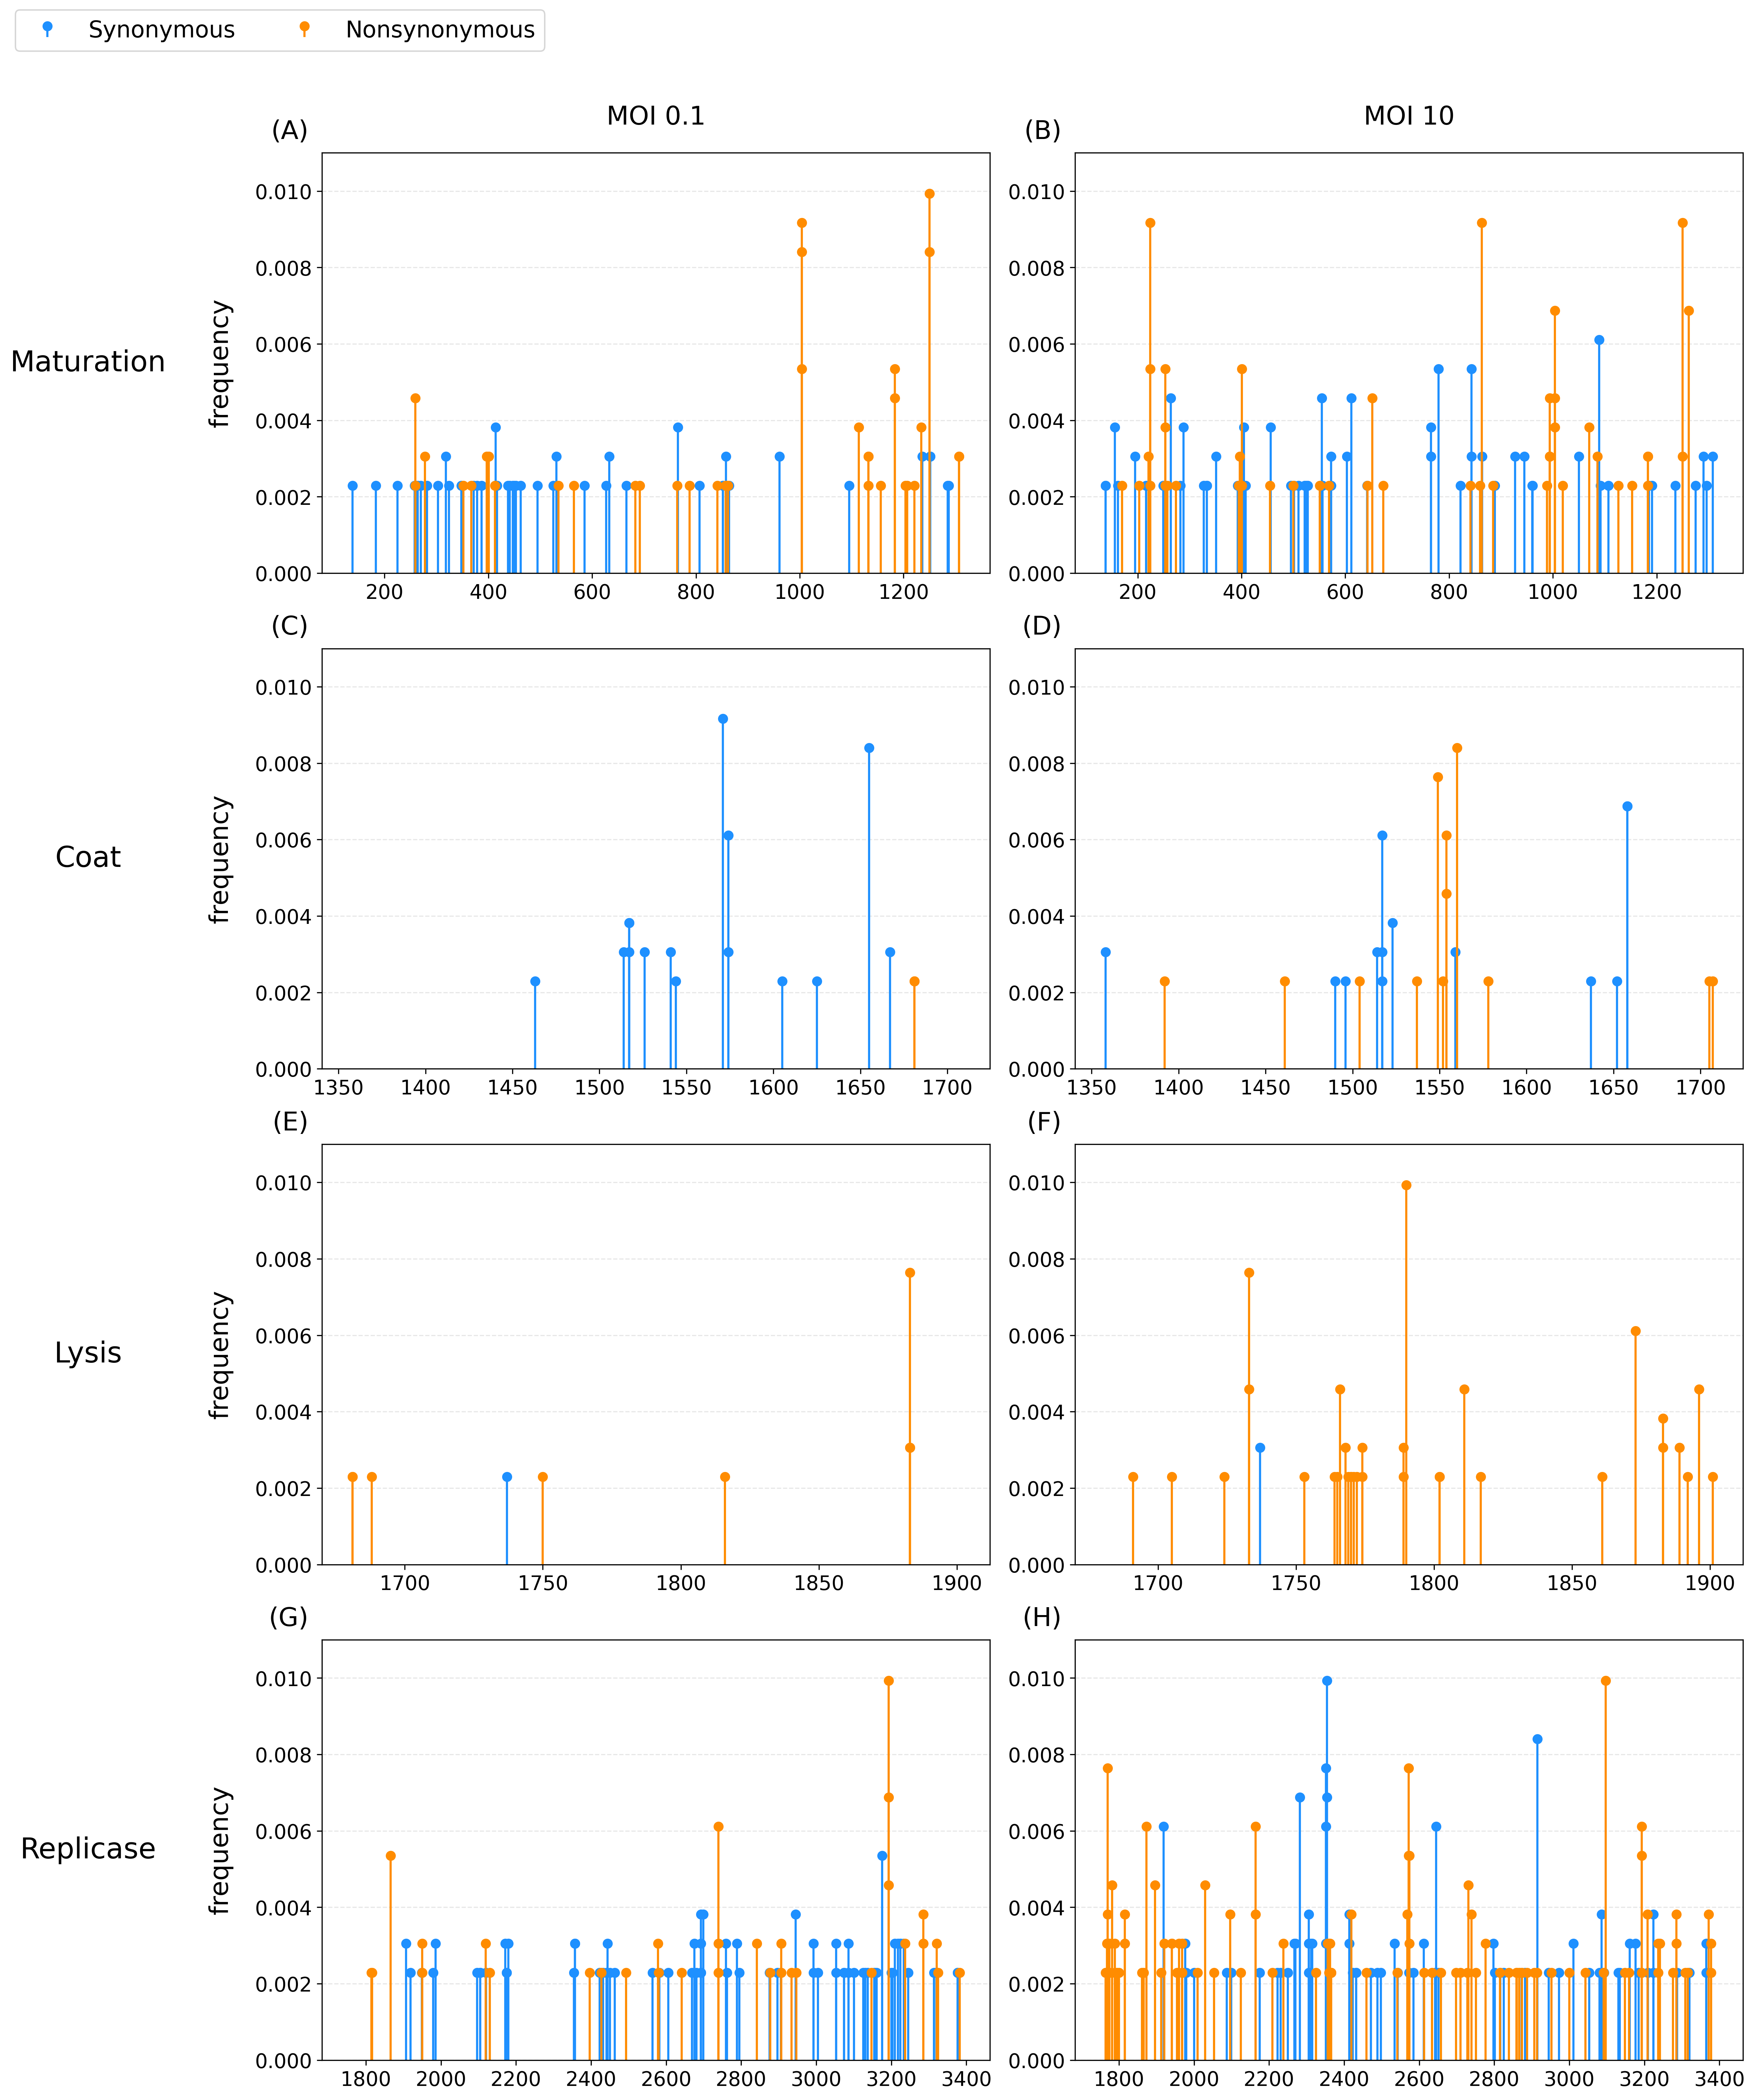

In [5]:
plot_full_mutation_grid(moi10_freqs,moi01_freqs)

## Plot MOI mean freqs syn and nonsyn
**Figure 2A**

In [6]:
def create_summary_ferq_df(freqs_with_metadata_df, threshold, greater_than=True):
    moi = '10' if any(freqs_with_metadata_df.columns.str.contains('moi10')) else '0.1'
    freqs_with_metadata_df = freqs_with_metadata_df[freqs_with_metadata_df['passage']==10]
    if greater_than:
        g = '>'
        summary_freq_df = freqs_with_metadata_df[freqs_with_metadata_df['freq']>threshold]
    else:
        g = '<'
        summary_freq_df = freqs_with_metadata_df[freqs_with_metadata_df['freq']<=threshold]
    summary_freq_df = summary_freq_df.groupby(['line','protein']).agg(
        median_freq=('freq','median'),mean_freq=('freq','mean'),max_freq=('freq','max'), sum_freq=('freq','sum'))
    summary_freq_df['log10_median'] = np.log10(summary_freq_df['median_freq'])
    summary_freq_df['log10_mean'] = np.log10(summary_freq_df['mean_freq'])
    summary_freq_df.name = f'MOI-{moi}_summary_freq_df, freq {g} {threshold}'
    
    return summary_freq_df

def plot_moi_mean_freqs_syn_nonsyn_v2(
    moi10_syn_summary_df,
    moi10_nonsyn_summary_df,
    moi01_syn_summary_df,
    moi01_nonsyn_summary_df,
    value_col="mean_freq",
    save_path=None,
    figsize=(14, 8),
    jitter=0.06,
    seed=1,
):

    rng = np.random.default_rng(seed)

    protein_order = ["mat", "cp", "lys", "rep"]

    protein_names = {
        "mat": "Maturation",
        "cp": "Coat",
        "lys": "Lysis",
        "rep": "Replicase",
    }

    def prepare_df(df, moi_label, mut_type):
        d = df.copy()

        if isinstance(d.index, pd.MultiIndex):
            d = d.reset_index()
        else:
            d = d.reset_index(drop=False)

        if "line" not in d.columns or "protein" not in d.columns:
            raise ValueError(
                "Each summary df must contain 'line' and 'protein' "
                "either as columns or as index levels."
            )

        if value_col not in d.columns:
            raise ValueError(f"Column '{value_col}' was not found in one of the dfs.")

        d = d[["line", "protein", value_col]].copy()
        d["protein"] = (
            d["protein"]
            .astype(str)
            .str.lower()
            .str.strip()
        )
        d["MOI"] = moi_label
        d["mut_type"] = mut_type
        return d

    plot_df = pd.concat(
        [
            prepare_df(moi01_syn_summary_df, "MOI 0.1", "Syn"),
            prepare_df(moi01_nonsyn_summary_df, "MOI 0.1", "Nonsyn"),
            prepare_df(moi10_syn_summary_df, "MOI 10", "Syn"),
            prepare_df(moi10_nonsyn_summary_df, "MOI 10", "Nonsyn"),
        ],
        ignore_index=True,
    )

    plot_df = plot_df[plot_df["protein"].isin(protein_order)].copy()

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=True)
    axes = axes.flatten()

    x_base = {"Syn": 0, "Nonsyn": 1}
    moi_offsets = {"MOI 0.1": -0.10, "MOI 10": 0.10}

    colors = {
        "MOI 0.1": "tab:blue",
        "MOI 10": "tab:red",
    }

    for ax, prot in zip(axes, protein_order):
        prot_df = plot_df[plot_df["protein"] == prot]

        for mut_type in ["Syn", "Nonsyn"]:
            for moi_label in ["MOI 0.1", "MOI 10"]:
                sub = prot_df[
                    (prot_df["mut_type"] == mut_type)
                    & (prot_df["MOI"] == moi_label)
                ]

                if sub.empty:
                    continue

                x_center = x_base[mut_type] + moi_offsets[moi_label]
                x_vals = x_center + rng.uniform(-jitter, jitter, size=len(sub))

                ax.scatter(
                    x_vals,
                    sub[value_col],
                    s=150,
                    color=colors[moi_label],
                    edgecolor="black",
                    linewidth=0.85,
                    alpha=0.8,
                    label=moi_label,
                )

        ax.set_title(protein_names[prot], fontsize=18) # , fontweight="bold"
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Syn", "Nonsyn"], fontsize=13)
        ax.set_xlim(-0.5, 1.5)
        ax.grid(axis="y", alpha=0.25)

    axes[0].set_ylabel("Mean mutation frequency", fontsize=15)
    axes[2].set_ylabel("Mean mutation frequency", fontsize=15)

    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="lower center",
        ncol=2,
        frameon=True,
        fontsize=13,
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, axes

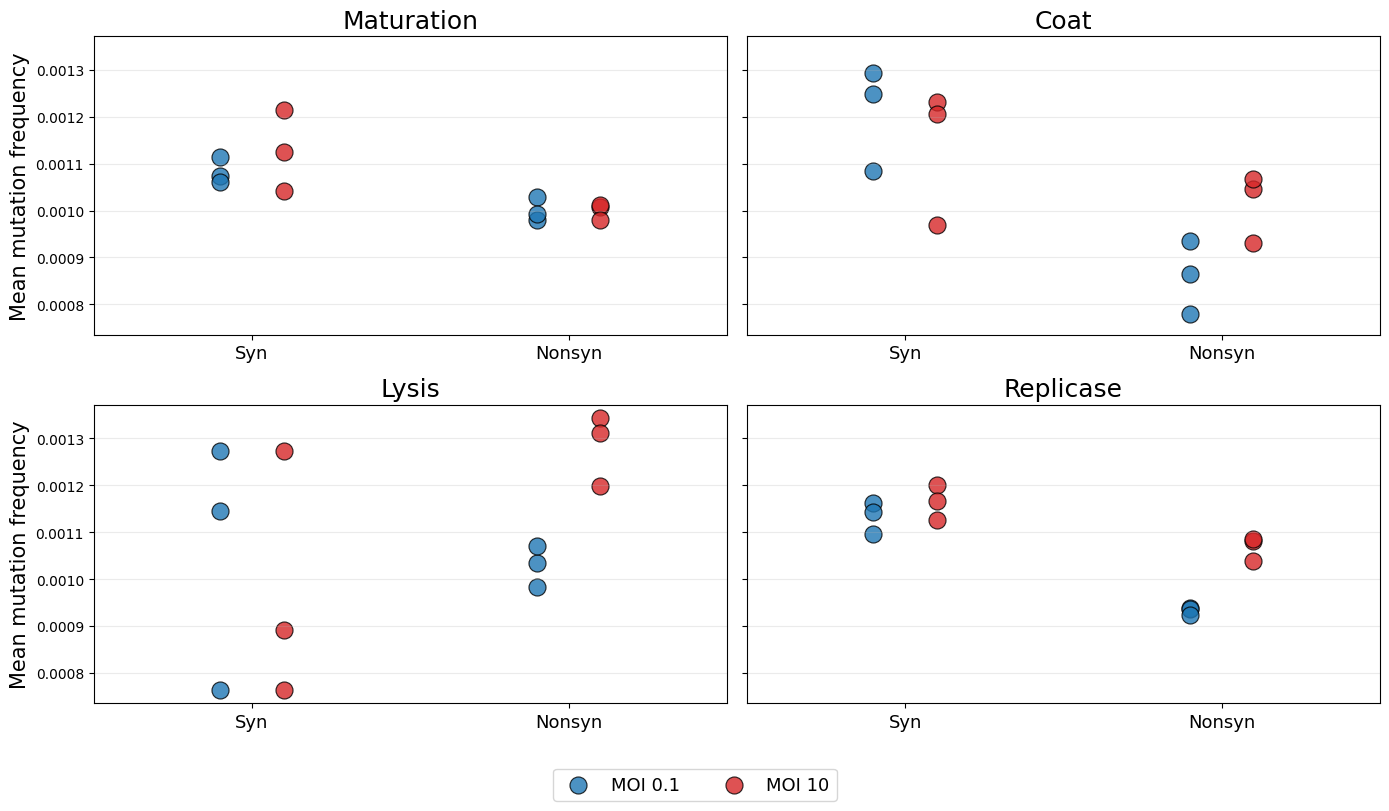

In [8]:
# summary freq dfs, freq < 0.01
# --- freqs
moi10_freqs_nonsyn = moi10_freqs[(moi10_freqs['syn_nonsyn']=='nonsyn')].copy()  
moi10_freqs_syn = moi10_freqs[(moi10_freqs['syn_nonsyn']=='syn')].copy() 

moi01_freqs_nonsyn = moi01_freqs[moi01_freqs['syn_nonsyn']=='nonsyn'].copy()  
moi01_freqs_syn = moi01_freqs[moi01_freqs['syn_nonsyn']=='syn'].copy() 

# summary freq dfs (syn/nonsyn), freq < 0.01
summary_freq_df_10_nonsyn = create_summary_ferq_df(moi10_freqs_nonsyn, 0.01, False)
summary_freq_df_10_syn = create_summary_ferq_df(moi10_freqs_syn, 0.01, False)

summary_freq_df_01_nonsyn = create_summary_ferq_df(moi01_freqs_nonsyn, 0.01, False)
summary_freq_df_01_syn = create_summary_ferq_df(moi01_freqs_syn, 0.01, False)

fig, axes = plot_moi_mean_freqs_syn_nonsyn_v2(
    moi10_syn_summary_df=summary_freq_df_10_syn,
    moi10_nonsyn_summary_df=summary_freq_df_10_nonsyn,
    moi01_syn_summary_df=summary_freq_df_01_syn,
    moi01_nonsyn_summary_df=summary_freq_df_01_nonsyn,
    jitter=0
)

## Syn mutation analysis
**Figure S3**

In [9]:
moi10_SR_df = pd.read_csv(DATA_DIR / "moi10_processed_shortread_freqs.csv")
moi10_SR_df = moi10_SR_df[moi10_SR_df['line'].isin(['E','G','H'])]
moi10_SR_mat_rep_syn = moi10_SR_df[(moi10_SR_df['protein'].isin(['rep','mat']))&(moi10_SR_df['syn_nonsyn']=='syn')&(moi10_SR_df['passage']!=0)]
moi01_freqs_mat_rep_syn = moi01_freqs[(moi01_freqs['protein'].isin(['rep','mat']))&(moi01_freqs['syn_nonsyn']=='syn')&(moi01_freqs['adaptive_moi0.1']=='nonada')]

In [10]:
def get_reg_params(df):
    """Calculates regression parameters for the given DataFrame."""
    x = df['passage']
    y = df['freq']
    slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
    return slope, intercept, r_val**2

def plot_moi_shifted_boxplot(df_moi01, df_moi10):
    # 1. Calculate regression stats
    slope01, intercept01, r2_01 = get_reg_params(df_moi01)
    slope10, intercept10, r2_10 = get_reg_params(df_moi10)

    fig, ax = plt.subplots(figsize=(10, 6))

    def get_bp_data(df):
        passages = sorted(df['passage'].unique())
        return [df[df['passage'] == p]['freq'] for p in passages], np.array(passages)

    data01, pass01 = get_bp_data(df_moi01)
    data10, pass10 = get_bp_data(df_moi10)

    offset = 0.05
    pos01 = pass01 - offset
    pos10 = pass10 + offset

    def get_style(color):
        return {
            "patch_artist": True,
            "manage_ticks": False,
            "widths": 0.4,
            "boxprops": dict(facecolor=color, alpha=0.6, color=color, edgecolor='black', linewidth=1.5),
            "medianprops": dict(color=color, linewidth=2),
            "whiskerprops": dict(color='black'),
            "capprops": dict(color='black'),
            "flierprops": dict(marker='o', markerfacecolor=color, markeredgecolor=color, alpha=0.5)
        }

    ax.boxplot(data01, positions=pos01, **get_style('#2c7bb6'))
    ax.boxplot(data10, positions=pos10, **get_style('#d7191c'))

    x_range = np.array([0, 10])
    ax.plot(x_range, slope01 * x_range + intercept01, 
            color='#2c7bb6', linestyle='--', linewidth=2)
    ax.plot(x_range, slope10 * x_range + intercept10, 
            color='#d7191c', linestyle='--', linewidth=2)

    ax.set_xlabel("passage", fontsize=18, labelpad=15)
    ax.set_ylabel("syn frequency", fontsize=18, labelpad=15)
    
    ax.set_xlim(-0.5, 11)
    ax.set_ylim(0, 0.0035)
    ax.set_xticks([0, 3, 5, 7, 8, 10])
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

    text_str = (f"MOI 0.1 Slope: {slope01:.2e}\n"
                f"MOI 10.0 Slope: {slope10:.2e}")
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='None', alpha=0.8))

    legend_elements = [Line2D([0], [0], color='#2c7bb6', lw=2, label='MOI 0.1'),
                       Line2D([0], [0], color='#d7191c', lw=2, label='MOI 10')]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.001, 0.88), fontsize=16)
    
    plt.gcf().set_dpi(300)
    plt.tight_layout()
    plt.show()



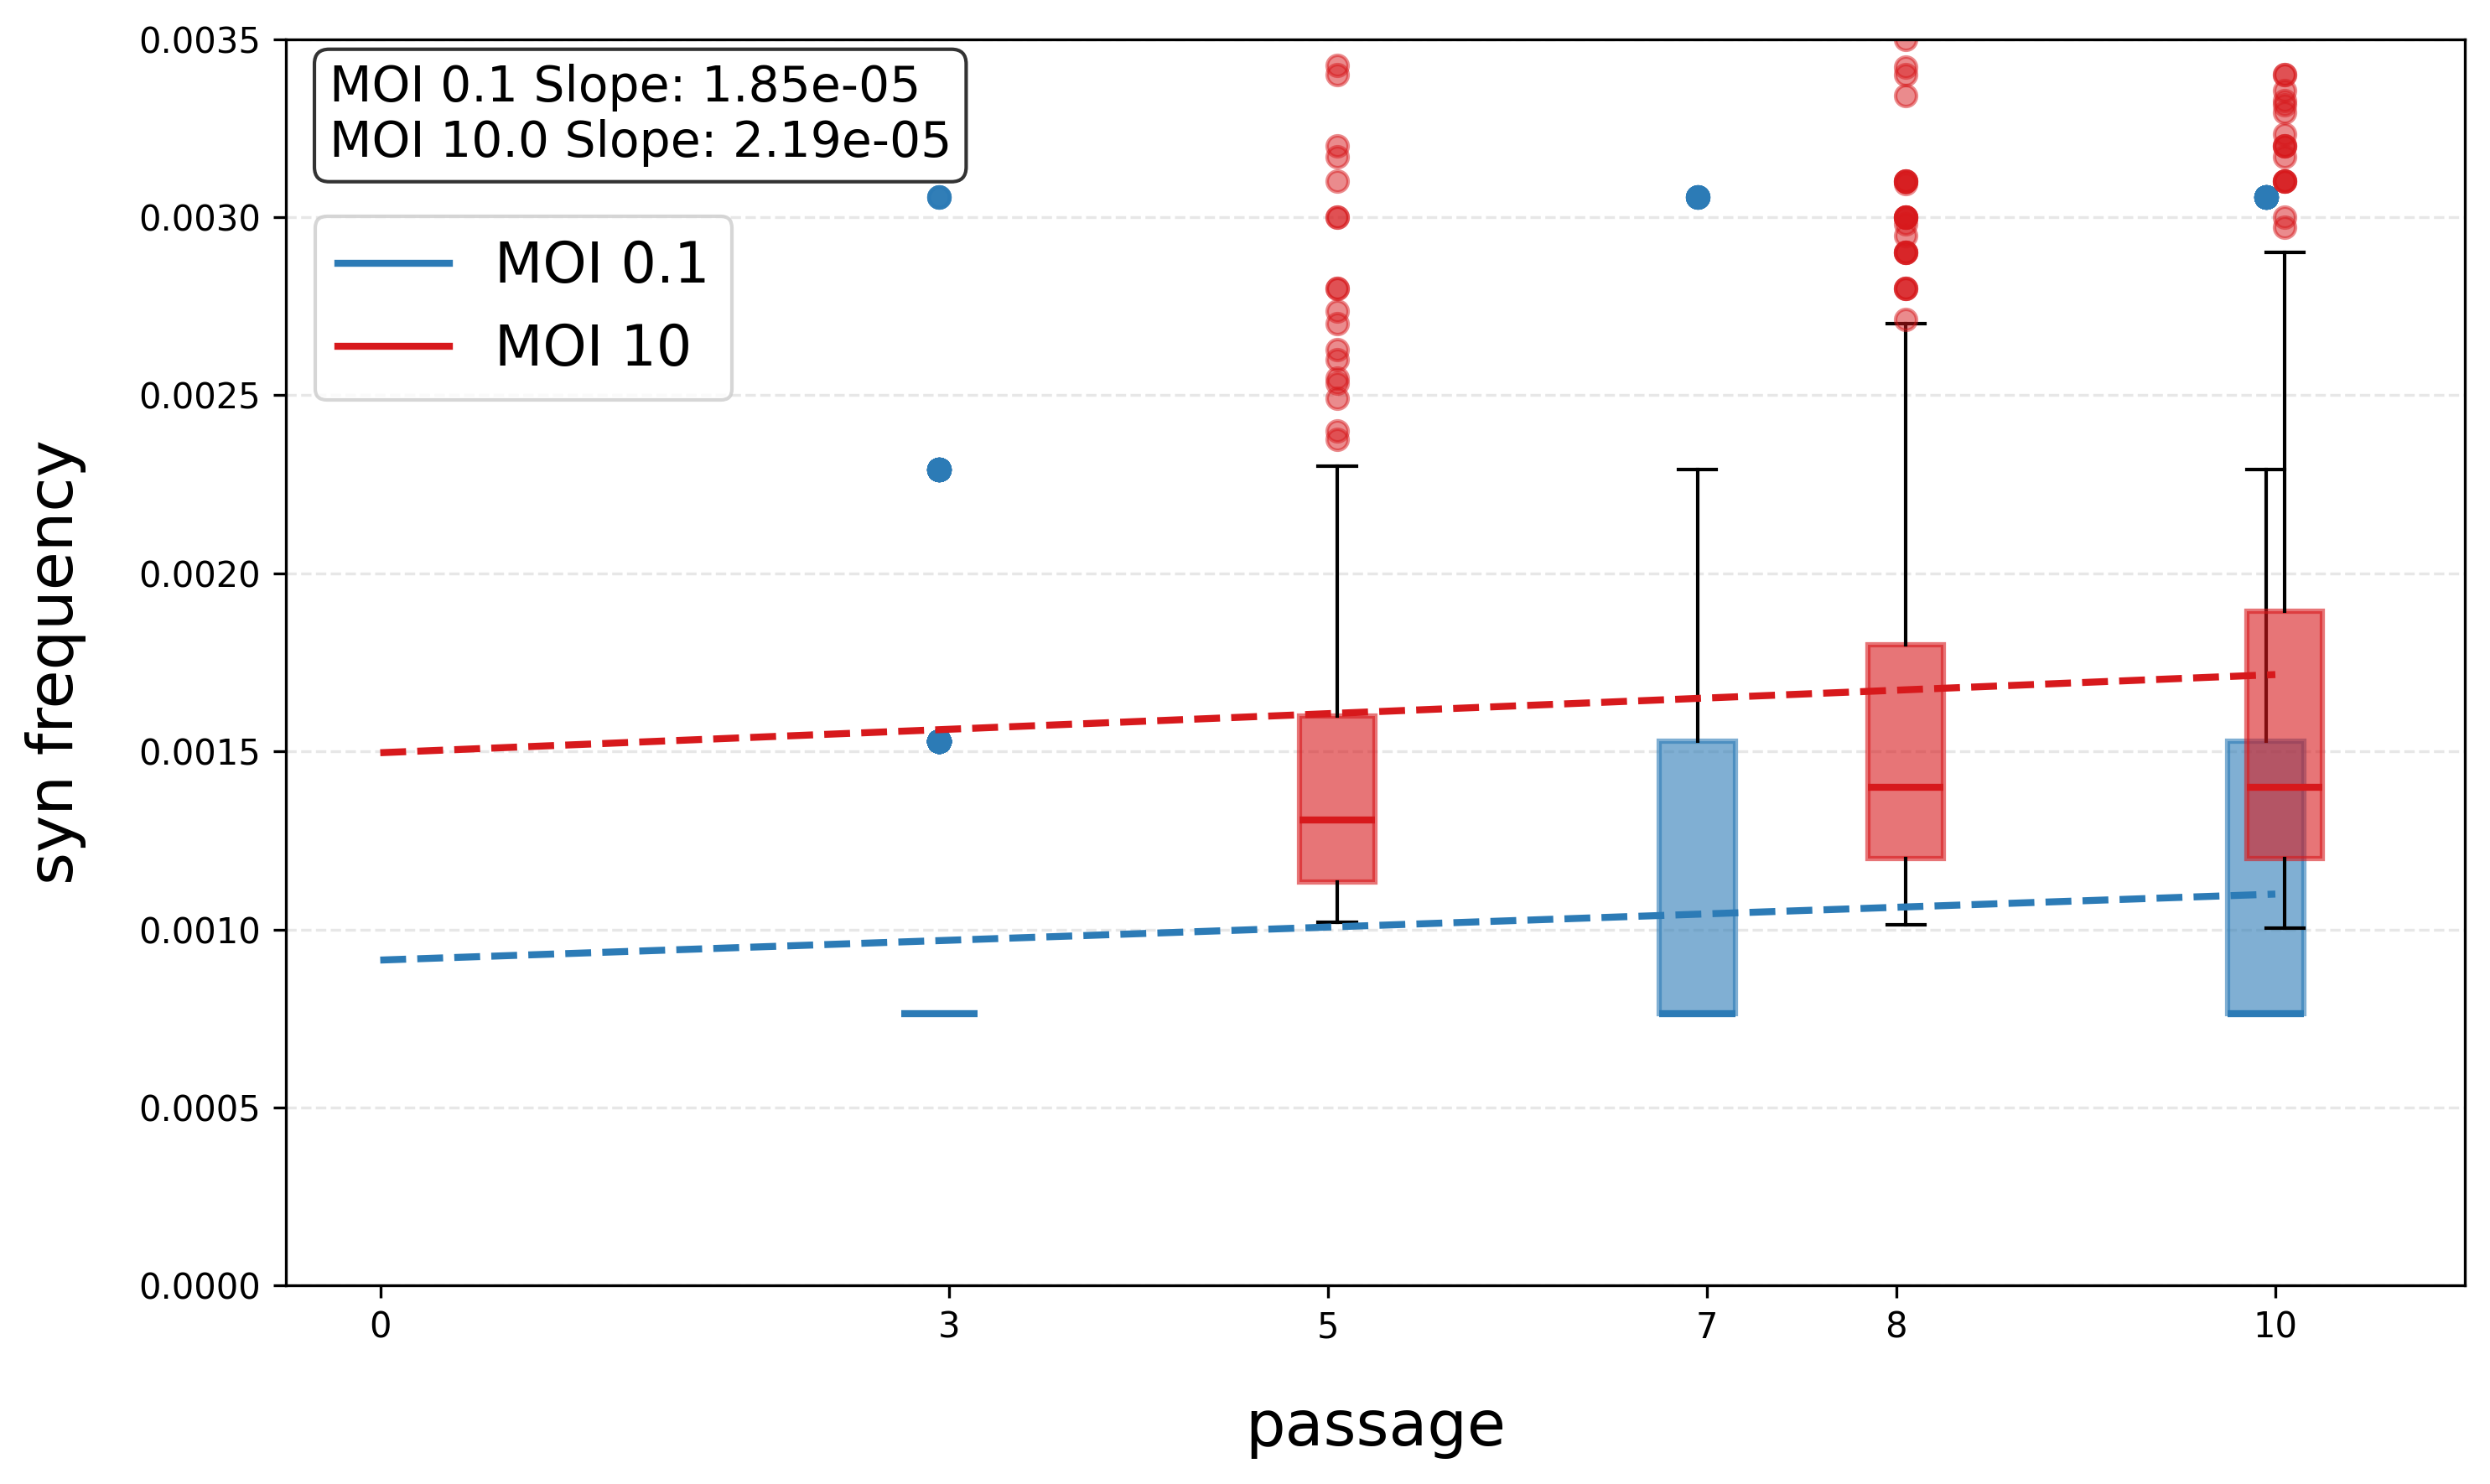

In [15]:
plot_moi_shifted_boxplot(moi01_freqs_mat_rep_syn[moi01_freqs_mat_rep_syn['freq']<0.01], moi10_SR_mat_rep_syn[moi10_SR_mat_rep_syn['freq']<0.01])